# Introduction

The target audience for this analysis is policymakers and development organizations, such as the World Bank, UNICEF, and WHO, that must decide how to allocate limited resources for water, sanitation, and hygiene (WASH) programs. Because funding is constrained, policymakers need evidence on which countries face the greatest WASH challenges and which aspects of WASH are most closely associated with poor health outcomes.

This project combines DHS and World Bank data to examine the relationship between WASH indicators and child health outcomes across developing countries. Specifically, the analysis explores how access to water, sanitation, and hygiene services relates to measures of child mortality and disease burden. Using exploratory data analysis, SQL queries, and regression modeling, the project identifies countries with the greatest needs and constructs a WASH Investment Urgency Index to help prioritize future investments. The goal is to provide an evidence-based framework for targeting resources where they may generate the largest health benefits.


DHS + World Bank Data Collection

In [3]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import plotly.express as px
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler

### Step 1: Get all country codes from DHS

In [5]:
#request country data from DHS
countries_url = "https://api.dhsprogram.com/rest/dhs/countries?f=json"
req = requests.get(countries_url)
dhs_country_response = req.json()

for country in dhs_country_response["Data"]:
    print(country["DHS_CountryCode"] + " : " + country["CountryName"])

country_codes = [country["DHS_CountryCode"] for country in dhs_country_response["Data"]] # Create a list of all DHS country codes

# Build a mapping from DHS 2-letter code to ISO3 for merging with World Bank data later
iso3_map = {country["DHS_CountryCode"]: country["ISO3_CountryCode"] for country in dhs_country_response["Data"]} # Create a dictionary to map DHS 2-letter country codes to ISO3 3-letter codes
# Build a mapping from DHS 2-letter code to geographic region
region_map = {c["DHS_CountryCode"]: c["RegionName"] for c in dhs_country_response["Data"]}

AF : Afghanistan
AL : Albania
AO : Angola
AM : Armenia
AZ : Azerbaijan
BD : Bangladesh
BJ : Benin
BO : Bolivia
BT : Botswana
BR : Brazil
BF : Burkina Faso
BU : Burundi
KH : Cambodia
CM : Cameroon
CV : Cape Verde
CF : Central African Republic
TD : Chad
CO : Colombia
KM : Comoros
CG : Congo
CD : Congo Democratic Republic
CI : Cote d'Ivoire
DR : Dominican Republic
EC : Ecuador
EG : Egypt
ES : El Salvador
EK : Equatorial Guinea
ER : Eritrea
SZ : Eswatini
ET : Ethiopia
GA : Gabon
GM : Gambia
GH : Ghana
GU : Guatemala
GN : Guinea
GY : Guyana
HT : Haiti
HN : Honduras
IA : India
ID : Indonesia
JO : Jordan
KK : Kazakhstan
KE : Kenya
KY : Kyrgyz Republic
LA : Lao People's Democratic Republic
LS : Lesotho
LB : Liberia
MD : Madagascar
MW : Malawi
MV : Maldives
ML : Mali
MR : Mauritania
MX : Mexico
MB : Moldova
MA : Morocco
MZ : Mozambique
MM : Myanmar
NM : Namibia
NP : Nepal
NC : Nicaragua
NI : Niger
NG : Nigeria
OS : Nigeria (Ondo State)
PK : Pakistan
PG : Papua New Guinea
PY : Paraguay
PE : Peru

## Step 2: Define indicators

In [7]:
# create a string to plug in to the request API code for all indicators
INDICATORS = ",".join([
    # Water
    "WS_SRCE_H_IMP",   # improved water source
    "WS_SRCE_H_PIP",   # piped water into dwelling
    "WS_SRCE_H_SRF",   # surface water (unsafe)
    "WS_TIME_H_ONP",   # water on premises
    "WS_TIME_H_M30",   # >30 min round trip to water
    "WS_WTRT_H_APP",   # appropriate water treatment
    "WS_WTRT_H_NTR",   # no water treatment
    # Sanitation / toilet
    "WS_TLET_H_IMP",   # improved sanitation facility
    "WS_TLET_H_NFC",   # open defecation (% of households)
    "WS_TLET_H_BAS",   # basic sanitation service
    "WS_MHEX_P_NFC",   # open defecation (% of population) — matches WB definition
    # Handwashing
    "WS_HNDW_H_BAS",   # basic handwashing (water + soap)
    "WS_HNDW_H_SOP",   # soap available
    # Disease outcomes
    "CH_DIAR_C_DIA",   # children with diarrhea (last 2 weeks)
    "ML_PMAL_C_RDT",   # malaria prevalence (RDT)
    "ML_FEVR_C_FEV",   # children with fever (last 2 weeks)
    # Child health outcomes
    "CM_ECMR_C_U5M",   # under-5 mortality rate
    "CM_ECMR_C_IMR",   # infant mortality rate
    "CM_ECMR_C_NNR",   # neonatal mortality rate
    "CN_NUTS_C_HA2",   # children stunted
    "CN_NUTS_C_WA2",   # children underweight
    # Malaria prevention
    "ML_NETP_H_ITN",   # households with ITN
    "ML_NETC_C_ITN",   # children under 5 slept under ITN
    "ML_IRSM_H_IRS",   # households sprayed with IRS
    # Controls
    "HC_ELEC_H_ELC",   # households with electricity
    "CH_VACS_C_BAS",   # children fully vaccinated
])

## Step 3: Fetch all countries — while loop for pagination

In [9]:
#Request selected variables' data for all countries
data_url = "https://api.dhsprogram.com/rest/dhs/data"
all_records = []

for country_code in country_codes:
    print(f"Fetching {country_code}...")
    page = 1 # Reset page number for each country to ensure data fetching starts from the first page

    while True: # Loop to fetch all paginated data
        params = {
            "countryIds":   country_code,
            "indicatorIds": INDICATORS,
            "breakdown":    "national",
            "f":            "json",
            "perPage":      1000,
            "page":         page,
        }

        req = requests.get(data_url, params=params)
        dhs_data_response = req.json() #requesting data after the above setup
        batch = dhs_data_response.get("Data", []) #getting the data from API by batch
        total = dhs_data_response.get("RecordCount", 0) #getting the count of requests from the API result
        all_records.extend(batch)#adding each batch to the total data pulled

        if len(all_records) >= total or len(batch) == 0: #count if the current recived data record is enough
            break #all data are requested and we break out the while-true loop
        page += 1 #prepare to extract data from next page

    print(f"{len(batch)} records")

print(f"\nTotal records fetched: {len(all_records)}")

Fetching AF...
26 records
Fetching AL...
39 records
Fetching AO...
87 records
Fetching AM...
89 records
Fetching AZ...
23 records
Fetching BD...
186 records
Fetching BJ...
121 records
Fetching BO...
88 records
Fetching BT...
8 records
Fetching BR...
25 records
Fetching BF...
151 records
Fetching BU...
81 records
Fetching KH...
109 records
Fetching CM...
134 records
Fetching CV...
0 records
Fetching CF...
18 records
Fetching TD...
66 records
Fetching CO...
120 records
Fetching KM...
48 records
Fetching CG...
57 records
Fetching CD...
83 records
Fetching CI...
114 records
Fetching DR...
129 records
Fetching EC...
6 records
Fetching EG...
155 records
Fetching ES...
8 records
Fetching EK...
0 records
Fetching ER...
39 records
Fetching SZ...
26 records
Fetching ET...
115 records
Fetching GA...
75 records
Fetching GM...
58 records
Fetching GH...
184 records
Fetching GU...
71 records
Fetching GN...
115 records
Fetching GY...
45 records
Fetching HT...
122 records
Fetching HN...
46 records
Fetc

## Step 4: Convert to DataFrame and clean columns

In [11]:
dhs_df = pd.DataFrame(all_records)#loading dataframe

dhs_df = dhs_df[["CountryName", "DHS_CountryCode", "SurveyYear",
                  "CharacteristicLabel", "IndicatorId", "Value"]] # Select only the relevant columns for further processing

dhs_df = dhs_df.rename(columns={
    "CountryName":         "country",
    "DHS_CountryCode":     "country_id",
    "SurveyYear":          "year",
    "CharacteristicLabel": "region",
    "IndicatorId":         "indicator",
    "CharacteristicLabel": "source_type",
    "Value":               "value",
})#renaming variables

print(dhs_df.shape)
dhs_df.head()

(7640, 6)


,country,country_id,year,source_type,indicator,value
0,Afghanistan,AF,2015,Total,CM_ECMR_C_NNR,22.0
1,Afghanistan,AF,2015,Total,CM_ECMR_C_NNR,25.0
2,Afghanistan,AF,2015,Total,CM_ECMR_C_IMR,45.0
3,Afghanistan,AF,2015,Total,CM_ECMR_C_IMR,50.0
4,Afghanistan,AF,2015,Total,CM_ECMR_C_U5M,55.0


## Step 5: Add iso3, then pivot wide

In [13]:
dhs_df["iso3"] = dhs_df["country_id"].map(iso3_map) #adding the iso code based on the country_id
dhs_df["region"] = dhs_df["country_id"].map(region_map) # geographic region from DHS API

dhs_wide = dhs_df.pivot_table(
    index=["country", "country_id", "iso3", "region", "year"],#using country and year as index
    columns="indicator", #make indicators into new columns
    values="value", # Use the 'value' column for the new table's cell values
    aggfunc="mean" # Aggregate duplicate entries by taking the mean of their 'value'
).reset_index()#transform long format to wide format

dhs_wide.columns.name = None

dhs_wide = dhs_wide.rename(columns={ #renaming the variables to make them readable
    "WS_SRCE_H_IMP": "improved_water_pct",
    "WS_SRCE_H_PIP": "piped_water_pct",
    "WS_SRCE_H_SRF": "surface_water_pct",
    "WS_TIME_H_ONP": "water_on_premises_pct",
    "WS_TIME_H_M30": "water_over30min_pct",
    "WS_WTRT_H_APP": "water_treatment_pct",
    "WS_WTRT_H_NTR": "no_water_treatment_pct",
    "WS_TLET_H_IMP": "improved_sanitation_pct",
    "WS_TLET_H_NFC": "open_defecation_hh_pct",
    "WS_TLET_H_BAS": "basic_sanitation_pct",
    "WS_MHEX_P_NFC": "open_defecation_pop_pct",
    "WS_HNDW_H_BAS": "basic_handwashing_pct",
    "WS_HNDW_H_SOP": "soap_available_pct",
    "CH_DIAR_C_DIA": "diarrhea_rate",
    "ML_PMAL_C_RDT": "malaria_prevalence_rdt",
    "ML_FEVR_C_FEV": "child_fever_rate",
    "CM_ECMR_C_U5M": "u5_mortality",
    "CM_ECMR_C_IMR": "infant_mortality",
    "CM_ECMR_C_NNR": "neonatal_mortality",
    "CN_NUTS_C_HA2": "stunting_rate",
    "CN_NUTS_C_WA2": "underweight_rate",
    "ML_NETP_H_ITN": "itn_hh_pct",
    "ML_NETC_C_ITN": "children_itn_pct",
    "ML_IRSM_H_IRS": "irs_sprayed_pct",
    "HC_ELEC_H_ELC": "electricity_pct",
    "HC_HEFF_H_MPH": "mobile_phone_pct",
    "ED_LITR_W_LIT": "female_literacy_pct",
    "RH_DELA_C_SKP": "skilled_birth_attendant_pct",
    "CH_VACS_C_BAS": "full_vaccination_pct",
})

## Step 6: Load World Bank data

In [15]:
#load World Bank CSV data
wb_raw = pd.read_csv("WorldBank_Data.csv")
wb_raw.sample(3)


,Country Name,Country Code,Series Name,Series Code,1990 [YR1990],1991 [YR1991],1992 [YR1992],1993 [YR1993],1994 [YR1994],1995 [YR1995],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
742,Czechia,CZE,"Life expectancy at birth, female (years)",SP.DYN.LE00.FE.IN,75.42,75.75,76.19,76.43,76.64,76.65,...,82.1,82,82,82.2,81.3,80.5,81.9,82.9,83,..
1251,Guinea,GIN,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,47.252,47.781,48.266,48.819,49.188,49.836,...,58.49,58.715,59.043,59.379,59.35,59.373,60.432,60.74,60.904,..
830,East Asia & Pacific,EAS,People using at least basic sanitation service...,SH.STA.BASS.RU.ZS,..,..,..,..,..,..,...,75.9596560392373,78.0124599439814,80.016947622559,82.0807282966712,84.1598012813366,86.2164884613402,88.1786419161404,90.1555649605484,90.9641304586568,..


In [16]:
# Step 6A: Melt from wide (one column per year) to long (one row per country-year) # This is the reverse of pivot_table, same from tidy data
year_cols = [c for c in wb_raw.columns if c.startswith("19") or c.startswith("20")] # Extract column names that represent years (starting with '19' or '20')

wb_long = wb_raw.melt(
    id_vars=["Country Name", "Country Code", "Series Name"],
    value_vars=year_cols,
    var_name="year_label",
    value_name="value"
)

wb_long.sample(3)

,Country Name,Country Code,Series Name,year_label,value
108398,Fiji,FJI,"Population, female (% of total population)",2021 [YR2021],50.354255594184
73126,Brunei Darussalam,BRN,Adjusted net national income per capita (const...,2011 [YR2011],28172.6435140604
6677,Turks and Caicos Islands,TCA,"Life expectancy at birth, total (years)",1991 [YR1991],70.54


In [17]:

# Extract 4-digit year from "2020 [YR2020]" style column names
wb_long["year"] = wb_long["year_label"].str.extract(r"(\d{4})").astype(int) # Extract the 4-digit year and convert to integer type
wb_long = wb_long.drop(columns="year_label")

# Replace ".." with NaN
wb_long["value"] = wb_long["value"].replace("..", float("nan")) # Replace World Bank's missing value indicator ".." with NaN
wb_long["value"] = pd.to_numeric(wb_long["value"]) # Convert the 'value' column to numeric type, coercing errors to NaN
wb_long = wb_long.rename(columns={"Country Code": "iso3"}) # Rename the 'Country Code' column to 'iso3' for consistency

# Step 6B: Pivot so each Series Name becomes its own column
wb_wide = wb_long.pivot_table( # Pivot the long format DataFrame to a wide format
    index=["iso3", "year"], # Use as the new index
    columns="Series Name", # Make 'Series Name' values into new columns
    values="value", # Use 'value' column as the values for the new table
    aggfunc="mean" # Aggregate duplicate entries by taking the mean of their 'value'
).reset_index() # Reset the index to turn 'iso3' and 'year' back into columns

wb_wide.columns.name = None # Remove the name of the columns index for cleaner display

wb_wide = wb_wide.rename(columns={ # Rename variable names for readability
    "Adjusted net national income per capita (constant 2015 US$)":        "gdp_per_capita",
    "Population, total":                                                   "population",
    "Life expectancy at birth, total (years)":                             "life_expectancy",
    "Life expectancy at birth, female (years)":                            "life_expectancy_female",
    "Life expectancy at birth, male (years)":                              "life_expectancy_male",
    "People practicing open defecation (% of population)":                "wb_open_defecation_pct",
    "People practicing open defecation, rural (% of rural population)":   "wb_open_defecation_rural_pct",
    "People practicing open defecation, urban (% of urban population)":   "wb_open_defecation_urban_pct",
    "People using at least basic sanitation services (% of population)":           "wb_basic_sanitation_pct",
    "People using at least basic sanitation services, rural (% of rural population)": "wb_basic_sanitation_rural_pct",
    "People using at least basic sanitation services, urban (% of urban population)": "wb_basic_sanitation_urban_pct",
    "Population, female (% of total population)":                         "population_female_pct",
    "Population, male (% of total population)":                           "population_male_pct",
})

print(wb_wide.shape)
wb_wide.head() # check output

(9275, 15)


,iso3,year,gdp_per_capita,life_expectancy_female,life_expectancy_male,life_expectancy,wb_open_defecation_pct,wb_open_defecation_rural_pct,wb_open_defecation_urban_pct,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population
0,ABW,1990,NaN,75.701,69.543,72.546,NaN,NaN,NaN,NaN,NaN,NaN,50.928872,49.071128,62753.0
1,ABW,1991,NaN,75.697,69.589,72.592,NaN,NaN,NaN,NaN,NaN,NaN,51.048194,48.951806,65896.0
2,ABW,1992,NaN,75.700,69.724,72.717,NaN,NaN,NaN,NaN,NaN,NaN,51.165188,48.834812,69005.0
3,ABW,1993,NaN,75.714,69.813,72.777,NaN,NaN,NaN,NaN,NaN,NaN,51.236088,48.763912,73685.0
4,ABW,1994,NaN,75.731,69.827,72.796,NaN,NaN,NaN,NaN,NaN,NaN,51.308231,48.691769,77595.0


## Step 7: Join DHS + World Bank on iso3 + year

In [19]:
## Step 7: Join DHS + World Bank on iso3 + year  (SQL version)

# 1. Create an in-memory SQLite database # ":memory:" means no file is written to disk; it disappears when the session ends
conn = sqlite3.connect(":memory:")

# 2. Load both DataFrames into the database as SQL tables  # to_sql() is the pandas equivalent of CREATE TABLE + INSERT
dhs_wide.to_sql("dhs", conn, if_exists="replace", index=False)
wb_wide.to_sql("wb",  conn, if_exists="replace", index=False)

# 3. SQL join query 
# LEFT JOIN keeps every row from dhs (left table) and adds matching wb columns. # Rows in dhs with no match in wb get NULL for the wb columns — same as how="left" in pd.merge().# We join on two keys: iso3 AND year, so each row is uniquely identified by country-year.
query = """
    SELECT dhs.*, wb.*
    FROM dhs
    LEFT JOIN wb
        ON dhs.iso3 = wb.iso3
       AND dhs.year = wb.year
"""

final_df = pd.read_sql(query, conn)

# wb.* brings iso3 and year along again, so we end up with duplicate columns. # keep="first" keeps the dhs versions (which come first in the SELECT) and drops the wb duplicates.
final_df = final_df.loc[:, ~final_df.columns.duplicated(keep="first")]

# 5. Close the connection (good practice)
conn.close()

print(final_df.shape)
final_df.head()

(371, 44)


,country,country_id,iso3,region,year,diarrhea_rate,full_vaccination_pct,infant_mortality,neonatal_mortality,u5_mortality,...,life_expectancy,wb_open_defecation_pct,wb_open_defecation_rural_pct,wb_open_defecation_urban_pct,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population
0,Afghanistan,AF,AFG,South & Southeast Asia,2015,30.55,42.00,47.5,23.5,58.5,...,62.270,15.923888,20.741933,1.316683,41.989819,37.511743,55.566316,49.457202,50.542798,33831764.0
1,Albania,AL,ALB,North Africa/West Asia/Europe,2008,6.10,93.05,18.5,10.5,22.0,...,78.248,0.471903,0.702247,0.241476,94.075816,90.503271,97.649643,50.678265,49.321735,2947314.0
2,Albania,AL,ALB,North Africa/West Asia/Europe,2017,6.00,81.45,NaN,NaN,NaN,...,78.900,0.064127,0.129719,0.019263,98.547296,98.041280,98.893407,50.506497,49.493503,2648285.0
3,Angola,AO,AGO,Sub-Saharan Africa,2006,NaN,NaN,NaN,NaN,NaN,...,52.965,30.063528,53.664115,12.087437,38.733882,16.822985,55.422974,50.800616,49.199384,20015279.0
4,Angola,AO,AGO,Sub-Saharan Africa,2011,NaN,NaN,53.5,25.0,96.5,...,58.093,29.181025,58.602398,9.994522,43.162063,19.623862,58.511981,50.677639,49.322361,24218352.0


## Step 8: Save Data

In [21]:
output_path = "wash_global_data.csv"
final_df.to_csv(output_path, index=False)

## Step 9: Merging other stats for regression

In [23]:
# Merge literacy + health_exp_urban into final_df

# 1. Read in both CSVs (same wide WB-style format )
literacy_raw     = pd.read_csv("literacy.csv",        skipfooter=3, engine="python")
health_raw       = pd.read_csv("health_exp_urban.csv", engine="python")

In [24]:
# 2. Helper function: wide → long → clean → wide again 
def wb_to_wide(df, rename_map):
    # Grab all the year columns (they look like "2000 [YR2000]")
    year_cols = [c for c in df.columns if "[YR" in c]

    # Melt to long format, keeping Country Code as the id
    long = df.melt(
        id_vars=["Country Code"],
        value_vars=year_cols,
        var_name="year_label",
        value_name="value"
    )

    # Pull out the 4-digit year from "2000 [YR2000]"
    long["year"] = long["year_label"].str.extract(r"(\d{4})").astype(int)
    long = long.drop(columns="year_label")

    # WB uses ".." for missing — convert to NaN
    long["value"] = long["value"].replace("..", float("nan"))
    long["value"] = pd.to_numeric(long["value"])
    long = long.rename(columns={"Country Code": "iso3"})

    # Single-indicator file: rename the value column
    col_name = list(rename_map.values())[0]
    long = long.rename(columns={"value": col_name})

    return long[["iso3", "year", col_name]]

# 3. Process literacy file # Only one Series, so wb_to_wide works directly
literacy_wide = wb_to_wide(literacy_raw, {"value": "female_literacy_pct"})

In [25]:
# 4. Process health_exp_urban file 

year_cols = [c for c in health_raw.columns if "[YR" in c]

# Melt to long, but keep Series Name so we can pivot it out later
health_long = health_raw.melt(
    id_vars=["Country Code", "Series Name"],
    value_vars=year_cols,
    var_name="year_label",
    value_name="value"
)

health_long["year"]  = health_long["year_label"].str.extract(r"(\d{4})").astype(int)
health_long["value"] = health_long["value"].replace("..", float("nan"))
health_long["value"] = pd.to_numeric(health_long["value"], errors="coerce")
health_long = health_long.rename(columns={"Country Code": "iso3"})
health_long = health_long.drop(columns="year_label")

# Pivot so each Series Name becomes its own column
health_wide = health_long.pivot_table(
    index=["iso3", "year"],
    columns="Series Name",
    values="value",
    aggfunc="mean"
).reset_index()
health_wide.columns.name = None

In [26]:
# Quick look at the columns before renaming
health_wide.describe()

,year,Current health expenditure (% of GDP),Urban population (% of total population)
count,16965.000000,5620.000000,16965.000000
mean,1992.000000,6.234979,50.872455
std,18.762216,2.826027,24.820531
min,1960.000000,1.222602,1.838567
25%,1976.000000,4.237668,30.824637
50%,1992.000000,5.526669,49.879362
75%,2008.000000,7.876840,69.868317
max,2024.000000,27.089685,100.000000


In [27]:
# Rename the two Series we actually want
health_wide = health_wide.rename(columns={
    "Current health expenditure (% of GDP)": "health_exp_pct",
    "Urban population (% of total population)": "urban_pct",
})

In [28]:
# 5. Read and clean the foreign aid file
aid_raw = pd.read_csv("foreign-aid-received-net.csv")

# Rename columns to match our iso3 + year merge keys
aid_wide = aid_raw.rename(columns={
    "Code": "iso3",
    "Year": "year",
    "Official development assistance (ODA) by recipient": "oda_received"
})[["iso3", "year", "oda_received"]]  # keep only what we need

In [29]:
# 6. Merge all three external sources (literacy/health/aid) in one go
conn = sqlite3.connect(":memory:")

final_df.to_sql("final",    conn, if_exists="replace", index=False)
literacy_wide.to_sql("lit", conn, if_exists="replace", index=False)
health_wide.to_sql("hlt",   conn, if_exists="replace", index=False)
aid_wide.to_sql("aid",      conn, if_exists="replace", index=False)

# Use a VIEW so the three joins are defined just once
conn.execute("""
    CREATE VIEW final_view AS
    SELECT f.*,
           lit.female_literacy_pct,
           hlt.health_exp_pct,
           hlt.urban_pct,
           aid.oda_received
    FROM final AS f
    LEFT JOIN lit ON f.iso3 = lit.iso3 AND f.year = lit.year
    LEFT JOIN hlt ON f.iso3 = hlt.iso3 AND f.year = hlt.year
    LEFT JOIN aid ON f.iso3 = aid.iso3 AND f.year = aid.year
""")

final_df = pd.read_sql("SELECT * FROM final_view", conn)
conn.close()

final_df.shape

(371, 48)

In [30]:
final_df.head()

,country,country_id,iso3,region,year,diarrhea_rate,full_vaccination_pct,infant_mortality,neonatal_mortality,u5_mortality,...,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population,female_literacy_pct,health_exp_pct,urban_pct,oda_received
0,Afghanistan,AF,AFG,South & Southeast Asia,2015,30.55,42.00,47.5,23.5,58.5,...,41.989819,37.511743,55.566316,49.457202,50.542798,33831764.0,NaN,10.105348,24.464912,4.974509e+09
1,Albania,AL,ALB,North Africa/West Asia/Europe,2008,6.10,93.05,18.5,10.5,22.0,...,94.075816,90.503271,97.649643,50.678265,49.321735,2947314.0,98.80911,5.444217,49.385070,3.707932e+08
2,Albania,AL,ALB,North Africa/West Asia/Europe,2017,6.00,81.45,NaN,NaN,NaN,...,98.547296,98.041280,98.893407,50.506497,49.493503,2648285.0,NaN,6.501119,55.980276,1.882814e+08
3,Angola,AO,AGO,Sub-Saharan Africa,2006,NaN,NaN,NaN,NaN,NaN,...,38.733882,16.822985,55.422974,50.800616,49.199384,20015279.0,NaN,2.398334,56.893903,2.163655e+08
4,Angola,AO,AGO,Sub-Saharan Africa,2011,NaN,NaN,53.5,25.0,96.5,...,43.162063,19.623862,58.511981,50.677639,49.322361,24218352.0,NaN,2.355619,60.843161,2.090825e+08


In [31]:
final_df.to_csv("final_df_5.csv", index=False)

## Part 9: SQL Code

In [33]:
# 1. LOAD DATA
final_df = pd.read_csv("final_df_5.csv")
print(f"Dataset shape: {final_df.shape}")

Dataset shape: (371, 48)


In [34]:
# 2. SET UP SQLITE FOR ANALYTICAL QUERIES
# We load the dataset into SQLite so we can run analytical SQL queries

conn = sqlite3.connect("wash_project.db")
final_df.to_sql("wash_main", conn, if_exists="replace", index=False)

371

In [35]:
# SQL Query 1: Dataset scope
# Purpose: Confirm the coverage of our dataset: how many countries, which years, and total number of observations.
q1 = """
SELECT COUNT(DISTINCT country) AS num_countries,
       MIN(year)               AS earliest_year,
       MAX(year)               AS latest_year,
       COUNT(*)                AS total_rows
FROM wash_main
"""
pd.read_sql(q1, conn)

,num_countries,earliest_year,latest_year,total_rows
0,87,1985,2024,371


In [36]:
# SQL Query 2: Countries with most missing WASH data # Purpose: Identify which countries have incomplete WASH records. # This reinforces the missing value analysis above and helps explain why some countries are excluded from modeling.
q2 = """
SELECT country, region,
       SUM(CASE WHEN improved_water_pct IS NULL THEN 1 ELSE 0 END) +
       SUM(CASE WHEN basic_handwashing_pct IS NULL THEN 1 ELSE 0 END) +
       SUM(CASE WHEN basic_sanitation_pct IS NULL THEN 1 ELSE 0 END) AS missing_wash_count
FROM wash_main
GROUP BY country, region
ORDER BY missing_wash_count DESC
LIMIT 10
"""
pd.read_sql(q2, conn)

,country,region,missing_wash_count
0,Indonesia,South & Southeast Asia,14
1,Peru,Latin America & Caribbean,14
2,Tanzania,Sub-Saharan Africa,13
3,Uganda,Sub-Saharan Africa,13
4,Dominican Republic,Latin America & Caribbean,12
5,Jordan,North Africa/West Asia/Europe,12
6,Senegal,Sub-Saharan Africa,12
7,Colombia,Latin America & Caribbean,11
8,Egypt,North Africa/West Asia/Europe,11
9,Ghana,Sub-Saharan Africa,11


In [37]:
# 3. EXPLORATORY DATA ANALYSIS (EDA) # We explore the relationships between WASH indicators and health outcomes to motivate our variable selection and understand the data structure before building models.


# SQL Query 3: Average WASH indicators by region # Purpose: Understand how WASH access varies across world regions.
q3 = """
SELECT region,
       ROUND(AVG(improved_water_pct), 2)     AS avg_improved_water,
       ROUND(AVG(basic_handwashing_pct), 2)  AS avg_handwashing,
       ROUND(AVG(basic_sanitation_pct), 2)   AS avg_sanitation,
       ROUND(AVG(open_defecation_hh_pct), 2) AS avg_open_defecation
FROM wash_main
GROUP BY region
ORDER BY avg_improved_water ASC
"""
pd.read_sql(q3, conn)

,region,avg_improved_water,avg_handwashing,avg_sanitation,avg_open_defecation
0,Oceania,45.50,30.60,22.10,16.70
1,Sub-Saharan Africa,65.75,21.21,25.56,26.79
2,Central Asia,81.01,77.65,94.90,0.29
3,South & Southeast Asia,81.72,61.73,50.13,25.74
4,Latin America & Caribbean,82.27,52.77,53.52,16.41
5,North Africa/West Asia/Europe,90.03,80.58,87.82,5.67


In [38]:
# SQL Query 4: Average health outcomes by region # Purpose: Compare disease burden across regions.

q4 = """
SELECT
    region,
    ROUND(AVG(diarrhea_rate), 2) AS avg_diarrhea,
    ROUND(AVG(infant_mortality), 2) AS avg_infant_mortality,
    ROUND(AVG(u5_mortality), 2) AS avg_u5_mortality
FROM wash_main
WHERE year BETWEEN 2020 AND 2024
    AND infant_mortality IS NOT NULL
    AND u5_mortality IS NOT NULL
GROUP BY region
ORDER BY AVG(u5_mortality) DESC
"""
pd.read_sql(q4, conn)

# Only using data from 2020-2024, missing data dropped, unit: number of child out of 1000


,region,avg_diarrhea,avg_infant_mortality,avg_u5_mortality
0,Sub-Saharan Africa,16.39,39.75,59.84
1,South & Southeast Asia,7.71,25.70,30.80
2,Central Asia,17.90,19.50,23.50
3,North Africa/West Asia/Europe,12.25,14.50,15.50


We expect regions with lower WASH access to show higher mortality rates, which motivates the WASH-health regression.# Only using data from 2020-2024, missing data dropped, unit: number of child out of 1000


In [39]:
# SQL Query 5: Countries with u5_mortality above global average 
# Purpose: Identify the highest-burden countries before building the Urgency Index.
# Using a subquery to compute the global average dynamically.
# Only using data from 2020-2024.

q5 = """
SELECT
    country,
    region,
    ROUND(AVG(u5_mortality), 2) AS avg_u5_mortality
FROM wash_main
WHERE year BETWEEN 2020 AND 2024
  AND u5_mortality > (
      SELECT AVG(u5_mortality)
      FROM wash_main
      WHERE year BETWEEN 2020 AND 2024
  )
GROUP BY country, region
ORDER BY avg_u5_mortality DESC
LIMIT 15
"""
pd.read_sql(q5, conn)

,country,region,avg_u5_mortality
0,Nigeria,Sub-Saharan Africa,106.5
1,Mali,Sub-Saharan Africa,92.5
2,Congo Democratic Republic,Sub-Saharan Africa,88.5
3,Cote d'Ivoire,Sub-Saharan Africa,76.0
4,Madagascar,Sub-Saharan Africa,72.0
5,Mozambique,Sub-Saharan Africa,60.0
6,Lesotho,Sub-Saharan Africa,56.0
7,Angola,Sub-Saharan Africa,51.5
8,Burkina Faso,Sub-Saharan Africa,51.5


Purpose: Identify the highest-burden countries before building the Urgency Index.
Using a subquery to compute the global average dynamically.
Only using data from 2020-2024.

In [40]:
# SQL Query 6: Countries below their regional average in water access 

q6 = """
SELECT
    w.country,
    w.region,
    ROUND(AVG(w.improved_water_pct), 2) AS avg_water_pct,
    ROUND(reg.avg_water, 2) AS region_avg_water
FROM wash_main w
JOIN (
    SELECT
        region,
        AVG(improved_water_pct) AS avg_water
    FROM wash_main
    WHERE year BETWEEN 2020 AND 2024
      AND improved_water_pct IS NOT NULL
    GROUP BY region
) reg
ON w.region = reg.region
WHERE w.year BETWEEN 2020 AND 2024
  AND w.improved_water_pct IS NOT NULL
GROUP BY w.country, w.region, reg.avg_water
HAVING AVG(w.improved_water_pct) < reg.avg_water
ORDER BY avg_water_pct ASC
LIMIT 15
"""
pd.read_sql(q6, conn)

,country,region,avg_water_pct,region_avg_water
0,Madagascar,Sub-Saharan Africa,48.0,77.73
1,Congo Democratic Republic,Sub-Saharan Africa,52.5,77.73
2,Niger,Sub-Saharan Africa,55.8,77.73
3,Mozambique,Sub-Saharan Africa,61.6,77.73
4,Angola,Sub-Saharan Africa,69.9,77.73
5,Zambia,Sub-Saharan Africa,71.4,77.73
6,Tanzania,Sub-Saharan Africa,73.5,77.73
7,Kenya,Sub-Saharan Africa,75.1,77.73
8,Cambodia,South & Southeast Asia,91.9,96.58
9,India,South & Southeast Asia,95.9,96.58


In [ ]:
Purpose: Find countries that lag behind their own region in water access.
These are countries where investment could have the highest relative impact.
Only using data from 2020-2024, missing data dropped.


In [41]:
# SQL Query 7: Rank countries by u5_mortality within each region 

q7 = """
SELECT
    country,
    region,
    ROUND(AVG(u5_mortality), 2) AS avg_u5_mortality,
    RANK() OVER (
        PARTITION BY region
        ORDER BY AVG(u5_mortality) DESC
    ) AS rank_in_region
FROM wash_main
WHERE year BETWEEN 2020 AND 2024
  AND u5_mortality IS NOT NULL
GROUP BY country, region
ORDER BY region, rank_in_region
"""
pd.read_sql(q7, conn)

,country,region,avg_u5_mortality,rank_in_region
0,Tajikistan,Central Asia,23.5,1
1,Jordan,North Africa/West Asia/Europe,15.5,1
2,India,South & Southeast Asia,42.0,1
3,Bangladesh,South & Southeast Asia,35.0,2
4,Nepal,South & Southeast Asia,35.0,2
5,Philippines,South & Southeast Asia,24.5,4
6,Cambodia,South & Southeast Asia,17.5,5
7,Nigeria,Sub-Saharan Africa,106.5,1
8,Mali,Sub-Saharan Africa,92.5,2
9,Congo Democratic Republic,Sub-Saharan Africa,88.5,3


Purpose: Show how each country compares to its regional peers, not just globally. A country may rank highly globally but be the worst in its region, signaling a localized investment opportunity.
Only using data from 2020-2024, missing data dropped.

In [42]:
# SQL Query 8: Running average of improved water access by year
q8 = """
SELECT year,
       ROUND(AVG(improved_water_pct), 2) AS avg_water_pct,
       ROUND(AVG(AVG(improved_water_pct)) OVER (ORDER BY year), 2) AS running_avg_water
FROM wash_main
GROUP BY year
ORDER BY year
"""
pd.read_sql(q8, conn)

,year,avg_water_pct,running_avg_water
0,1985,NaN,NaN
1,1986,NaN,NaN
2,1987,NaN,NaN
3,1988,NaN,NaN
4,1989,NaN,NaN
5,1990,89.90,89.90
6,1991,58.66,74.28
7,1992,46.08,64.88
8,1993,55.61,62.56
9,1994,60.29,62.11


Purpose: Track whether global water access has improved over time.
A rising running average would suggest positive trends in WASH investment.

## Data Quality Check

In [44]:
# Before any analysis, we perform a full quality check on the dataset.
# This includes checking for missing values, verifying data types, and checking for any oddities in key variables.

In [45]:
# A quick look at the structure of the dataset
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 371 entries, 0 to 370
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        371 non-null    str    
 1   country_id                     371 non-null    str    
 2   iso3                           371 non-null    str    
 3   region                         371 non-null    str    
 4   year                           371 non-null    int64  
 5   diarrhea_rate                  311 non-null    float64
 6   full_vaccination_pct           289 non-null    float64
 7   infant_mortality               327 non-null    float64
 8   neonatal_mortality             327 non-null    float64
 9   u5_mortality                   327 non-null    float64
 10  stunting_rate                  250 non-null    float64
 11  underweight_rate               249 non-null    float64
 12  electricity_pct                329 non-null    float64
 13  c

In [46]:
# Missing value summary (Table 1)
# We compute the number and percentage of missing values for every column that has at least one null. This tells us which variables have data gaps and helps us decide how to handle them before modeling.
missing = final_df.isnull().sum().reset_index()
missing.columns = ['Variable', 'Missing Count']
# Create 'Missing_pct' index
missing['Missing_pct'] = (missing['Missing Count'] / len(final_df) * 100).round(1)
missing = missing[missing['Missing Count'] > 0].sort_values('Missing_pct', ascending=False)
missing

,Variable,Missing Count,Missing_pct
20,open_defecation_pop_pct,351,94.6
14,irs_sprayed_pct,304,81.9
17,malaria_prevalence_rdt,291,78.4
44,female_literacy_pct,285,76.8
19,soap_available_pct,270,72.8
18,basic_handwashing_pct,270,72.8
30,no_water_treatment_pct,216,58.2
29,water_treatment_pct,215,58.0
15,children_itn_pct,214,57.7
16,itn_hh_pct,212,57.1


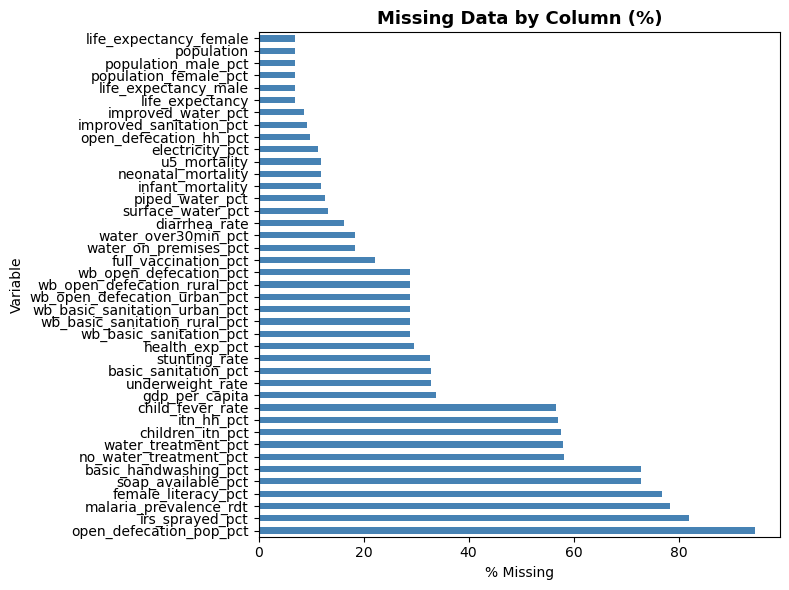

In [47]:
# Missing data chart
missing.plot(x='Variable', y='Missing_pct', kind='barh', figsize=(8, 6), color='steelblue', legend=False)
plt.title("Missing Data by Column (%)", fontsize=13, fontweight='bold')
plt.xlabel("% Missing")
plt.tight_layout()
plt.savefig("chart0_missingdata.png")
plt.show()

Most core mortality and WASH variables have relatively low missingness, while several detailed WASH indicators suffer from substantial data gaps. Therefore, the analysis prioritizes variables with higher coverage to maximize the number of countries included.

In [49]:
# Check for out-of-range values in percentage columns
pct_cols = [
    'basic_handwashing_pct', 'open_defecation_hh_pct',
    'improved_water_pct', 'basic_sanitation_pct',
    'full_vaccination_pct', 'urban_pct', 'female_literacy_pct'
]

print("Values > 100:")
print((final_df[pct_cols] > 100).sum())

print("\nValues < 0:")
print((final_df[pct_cols] < 0).sum())

Values > 100:
basic_handwashing_pct     0
open_defecation_hh_pct    0
improved_water_pct        0
basic_sanitation_pct      0
full_vaccination_pct      0
urban_pct                 0
female_literacy_pct       0
dtype: int64

Values < 0:
basic_handwashing_pct     0
open_defecation_hh_pct    0
improved_water_pct        0
basic_sanitation_pct      0
full_vaccination_pct      0
urban_pct                 0
female_literacy_pct       0
dtype: int64


Based on descriptive statistics and range checks, no implausible outliers were identified in the percentage variables. Extreme values (e.g. very high open defecation rates) reflect genuine country conditions rather than data errors, and are retained for analysis.

In [50]:
# Group by region — check if disease burden aligns with expectations
# Sub-Saharan Africa should show highest mortality rates
final_df.groupby('region')[['diarrhea_rate', 'infant_mortality', 'u5_mortality']].mean().round(2)

,diarrhea_rate,infant_mortality,u5_mortality
region,,,
Central Asia,12.66,43.50,52.17
Latin America & Caribbean,20.39,44.57,60.15
North Africa/West Asia/Europe,17.71,38.67,48.94
Oceania,15.60,35.50,50.50
South & Southeast Asia,12.98,48.83,64.49
Sub-Saharan Africa,19.33,69.52,118.27


In [51]:
# Descriptive statistics
final_df.describe()

,year,diarrhea_rate,full_vaccination_pct,infant_mortality,neonatal_mortality,u5_mortality,stunting_rate,underweight_rate,electricity_pct,child_fever_rate,...,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population,female_literacy_pct,health_exp_pct,urban_pct,oda_received
count,371.000000,311.000000,289.000000,327.000000,327.000000,327.000000,250.000000,249.000000,329.000000,161.000000,...,264.000000,264.000000,264.000000,345.000000,345.000000,3.450000e+02,86.000000,261.000000,371.000000,3.710000e+02
mean,2006.207547,18.037781,58.663668,57.996942,29.952599,90.666667,33.486800,17.869076,48.441945,23.785714,...,43.741967,35.984943,54.254506,50.289801,49.710199,5.340837e+07,55.028818,5.145670,40.443213,1.114429e+09
std,10.197909,6.913795,19.892344,27.132909,11.495266,54.346767,12.355375,10.839193,31.783878,9.236036,...,26.795874,27.561190,24.182863,1.173141,1.173141,1.466783e+08,28.081979,2.144130,18.235294,9.862185e+08
min,1985.000000,3.600000,6.450000,6.000000,4.000000,8.500000,6.900000,1.500000,1.900000,6.400000,...,2.965766,0.000000,11.245849,40.384789,45.927880,1.737930e+05,10.804020,1.717741,5.661007,-2.221884e+07
25%,1998.000000,13.775000,43.200000,36.500000,22.000000,48.250000,24.425000,9.700000,18.500000,16.400000,...,20.641737,13.820982,33.320671,49.798046,49.236618,9.004053e+06,29.653630,3.725335,26.517689,4.092532e+08
50%,2007.000000,17.350000,61.150000,54.500000,29.500000,79.500000,33.150000,16.100000,43.700000,23.000000,...,38.595474,28.674338,52.018948,50.218077,49.781923,1.694998e+07,51.775110,4.559941,37.984276,8.336738e+08
75%,2014.500000,22.000000,75.100000,77.000000,38.000000,123.500000,42.550000,23.600000,77.000000,30.400000,...,64.760360,51.507069,74.509284,50.763382,50.201954,3.879915e+07,83.746475,6.067106,53.012018,1.467804e+09
max,2024.000000,42.400000,95.150000,148.500000,69.500000,322.000000,60.400000,52.200000,100.000000,49.200000,...,98.767943,98.476921,98.893407,54.072120,59.615211,1.402618e+09,99.783280,13.588197,92.682237,6.190788e+09


In [52]:
# Descriptive statistics
final_df.describe()

,year,diarrhea_rate,full_vaccination_pct,infant_mortality,neonatal_mortality,u5_mortality,stunting_rate,underweight_rate,electricity_pct,child_fever_rate,...,wb_basic_sanitation_pct,wb_basic_sanitation_rural_pct,wb_basic_sanitation_urban_pct,population_female_pct,population_male_pct,population,female_literacy_pct,health_exp_pct,urban_pct,oda_received
count,371.000000,311.000000,289.000000,327.000000,327.000000,327.000000,250.000000,249.000000,329.000000,161.000000,...,264.000000,264.000000,264.000000,345.000000,345.000000,3.450000e+02,86.000000,261.000000,371.000000,3.710000e+02
mean,2006.207547,18.037781,58.663668,57.996942,29.952599,90.666667,33.486800,17.869076,48.441945,23.785714,...,43.741967,35.984943,54.254506,50.289801,49.710199,5.340837e+07,55.028818,5.145670,40.443213,1.114429e+09
std,10.197909,6.913795,19.892344,27.132909,11.495266,54.346767,12.355375,10.839193,31.783878,9.236036,...,26.795874,27.561190,24.182863,1.173141,1.173141,1.466783e+08,28.081979,2.144130,18.235294,9.862185e+08
min,1985.000000,3.600000,6.450000,6.000000,4.000000,8.500000,6.900000,1.500000,1.900000,6.400000,...,2.965766,0.000000,11.245849,40.384789,45.927880,1.737930e+05,10.804020,1.717741,5.661007,-2.221884e+07
25%,1998.000000,13.775000,43.200000,36.500000,22.000000,48.250000,24.425000,9.700000,18.500000,16.400000,...,20.641737,13.820982,33.320671,49.798046,49.236618,9.004053e+06,29.653630,3.725335,26.517689,4.092532e+08
50%,2007.000000,17.350000,61.150000,54.500000,29.500000,79.500000,33.150000,16.100000,43.700000,23.000000,...,38.595474,28.674338,52.018948,50.218077,49.781923,1.694998e+07,51.775110,4.559941,37.984276,8.336738e+08
75%,2014.500000,22.000000,75.100000,77.000000,38.000000,123.500000,42.550000,23.600000,77.000000,30.400000,...,64.760360,51.507069,74.509284,50.763382,50.201954,3.879915e+07,83.746475,6.067106,53.012018,1.467804e+09
max,2024.000000,42.400000,95.150000,148.500000,69.500000,322.000000,60.400000,52.200000,100.000000,49.200000,...,98.767943,98.476921,98.893407,54.072120,59.615211,1.402618e+09,99.783280,13.588197,92.682237,6.190788e+09


In [53]:
# Check unique values for key categorical variables
print("Unique regions:", final_df['region'].unique())
print("Number of unique countries:", final_df['country'].nunique())
print(f"Years covered: {final_df['year'].min()} – {final_df['year'].max()}")

Unique regions: <ArrowStringArray>
[       'South & Southeast Asia', 'North Africa/West Asia/Europe',
            'Sub-Saharan Africa',     'Latin America & Caribbean',
                  'Central Asia',                       'Oceania']
Length: 6, dtype: str
Number of unique countries: 87
Years covered: 1985 – 2024


## EXPLORATORY DATA ANALYSIS (EDA)

Before selecting our variables, we explore the relationships between all potential WASH indicators and health outcomes.
The heatmap and pairplot below inform our choice of X_vars and y_vars.

# Chart 1: Correlation Heatmap
We include all WASH-related and health outcome variables to see which pairs have the strongest correlations.
Strong negative correlations (green) between a WASH indicator and a health outcome confirm that the indicator is a good candidate for X_vars.
Strong positive correlations (red) between health outcomes confirm they measure similar underlying phenomena.

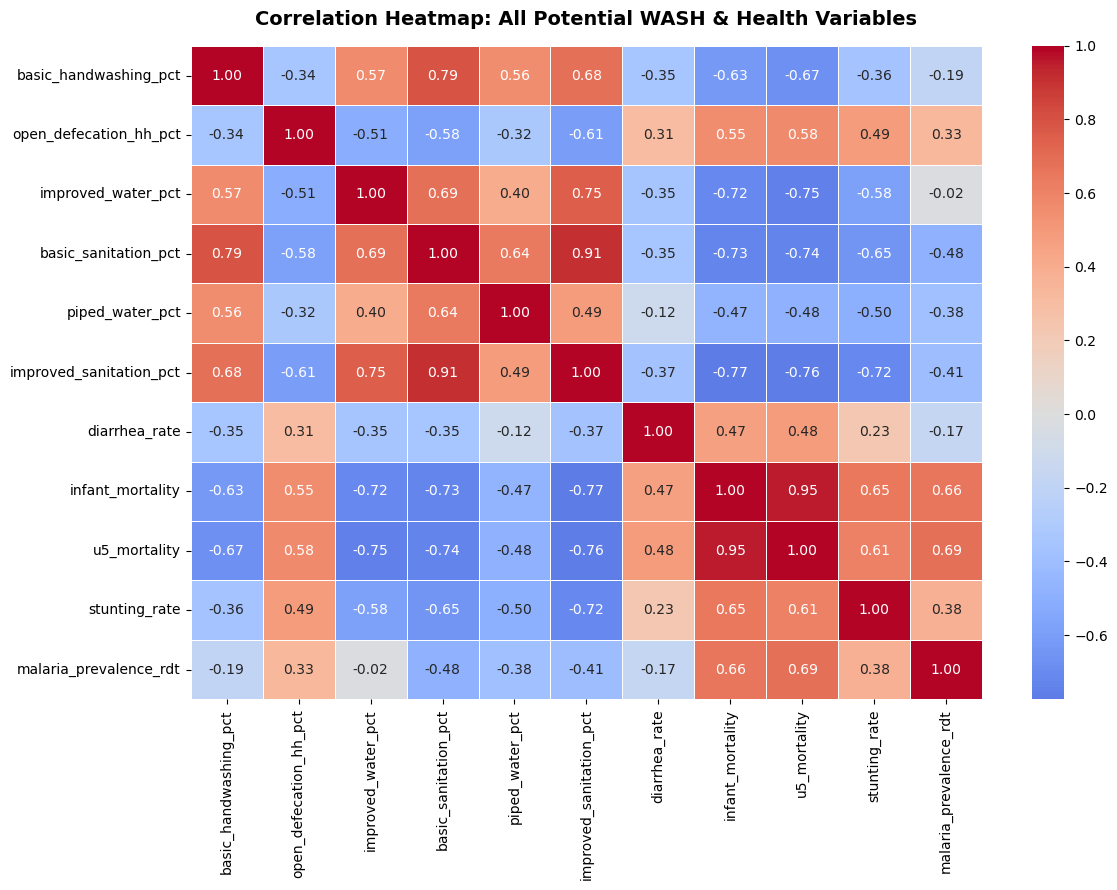

In [57]:
eda_vars = [
    'basic_handwashing_pct', 'open_defecation_hh_pct',
    'improved_water_pct', 'basic_sanitation_pct',
    'piped_water_pct', 'improved_sanitation_pct',
    'diarrhea_rate', 'infant_mortality',
    'u5_mortality', 'stunting_rate', 'malaria_prevalence_rdt'
]

corr_matrix = final_df[eda_vars].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, ax=ax
)
ax.set_title("Correlation Heatmap: All Potential WASH & Health Variables",
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("chart1_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

The heatmap shows strong negative correlations between WASH access indicators and child mortality outcomes, suggesting that better water, sanitation, and hygiene conditions are associated with improved health. Improved sanitation and improved water, basic handwashing, bopen defecation exhibit the strongest relationships with infant and under-5 mortality, supporting their inclusion as key explanatory variables in the regression analysis.

# Chart 2: Pairplot
We zoom in on the four WASH indicators most correlated with u5_mortality based on the heatmap above, and plot their pairwise relationships.
This helps us spot any non-linear patterns or outliers before modeling.

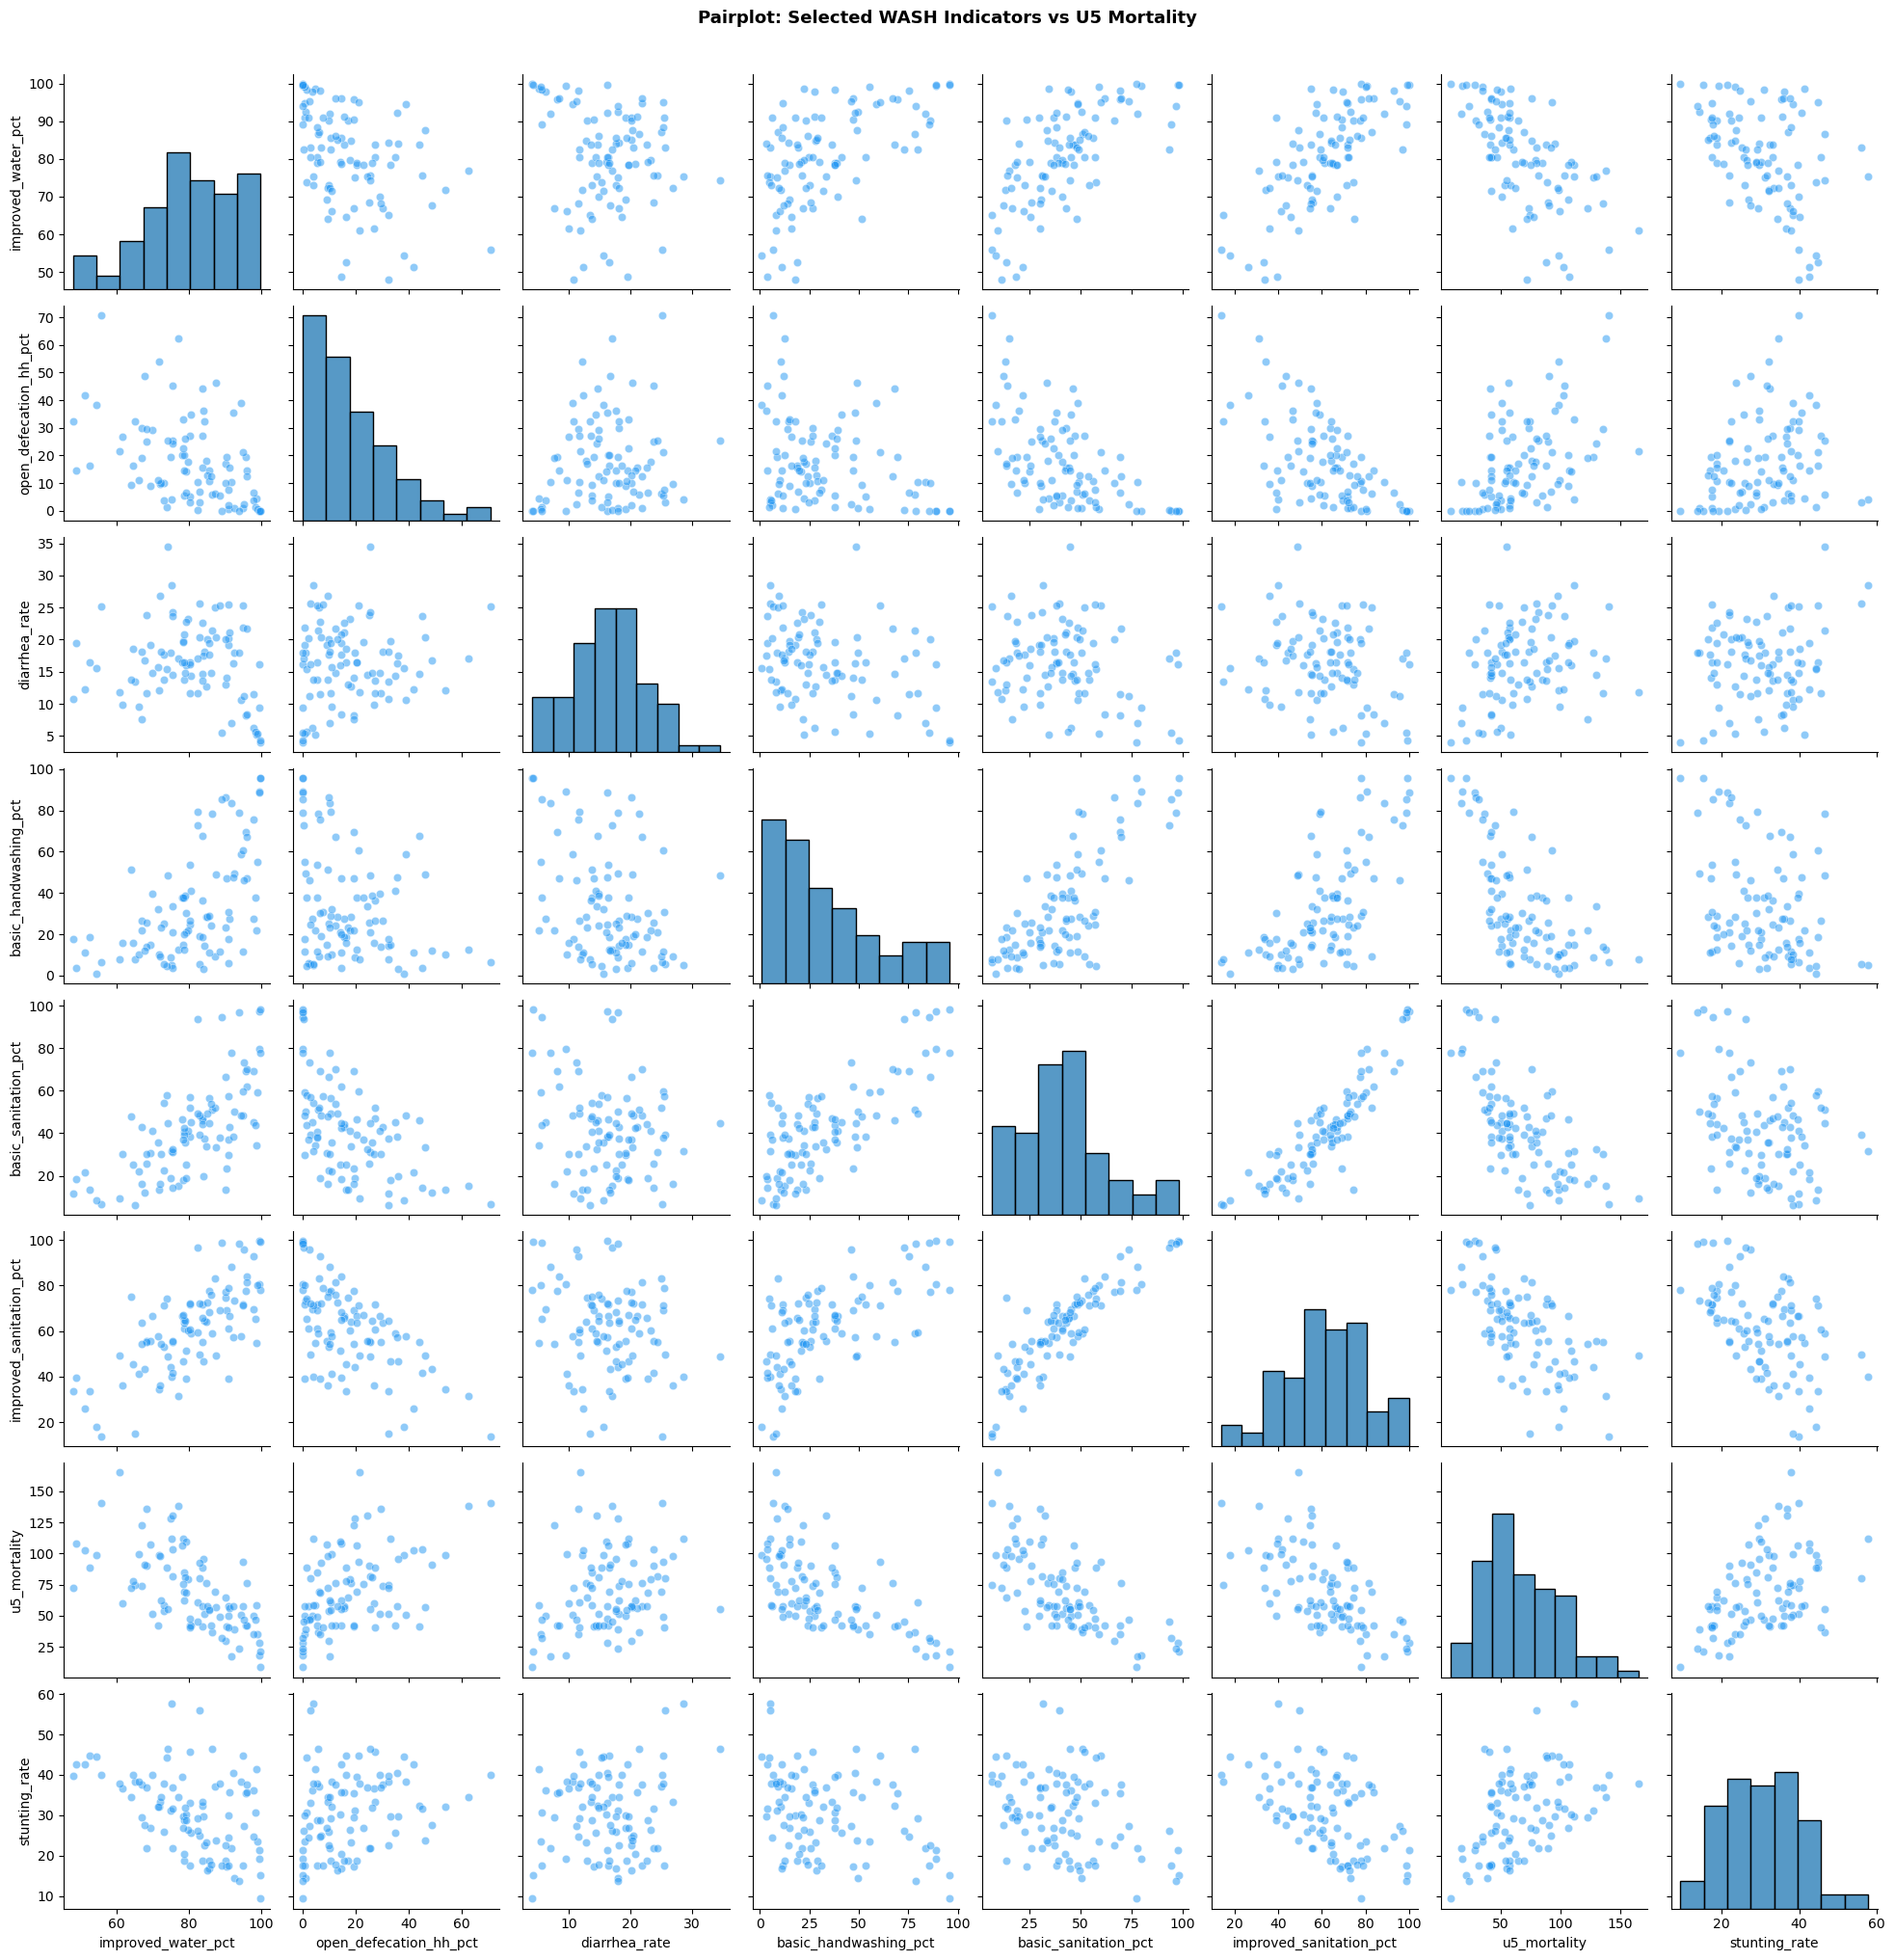

In [60]:
pairplot_vars = [
    'improved_water_pct', 'open_defecation_hh_pct', 'diarrhea_rate',
    'basic_handwashing_pct', 'basic_sanitation_pct', 'improved_sanitation_pct',
    'u5_mortality', 'stunting_rate'
]
pair_df = final_df[pairplot_vars].dropna()

g = sns.pairplot(pair_df, plot_kws={'alpha': 0.5, 'color': '#2196F3'})
g.figure.suptitle("Pairplot: Selected WASH Indicators vs U5 Mortality",
                   fontsize=13, fontweight='bold', y=1.02)
plt.savefig("chart2_pairplot.png", dpi=150, bbox_inches='tight')
plt.show()

The pairplot confirms the patterns observed in the correlation analysis. Countries with higher access to improved water, sanitation, and handwashing facilities generally exhibit lower under-5 mortality rates, while open defecation is associated with worse health outcomes. The relationships appear approximately linear, supporting the use of regression analysis to quantify the association between WASH conditions and child health.

## Relevant model (linear and logistic)

In [63]:
# WASH indicators (X): the main drivers of interest, which represent a country's sanitation and hygiene infrastructure.
X_vars = [
    'basic_handwashing_pct',
    'open_defecation_hh_pct',
    'improved_water_pct',
    'basic_sanitation_pct'
]

In [64]:
# Controls: variables that also affect health outcomes but are not the focus of our analysis. Including them isolates the WASH effect.
controls = [
    'gdp_per_capita',
    'urban_pct',
    'female_literacy_pct',
    'health_exp_pct',
    'full_vaccination_pct'
]

In [65]:
# Outcomes (y): health indicators that capture disease burden, particularly among children who are most vulnerable to poor sanitation.
y_vars = ['diarrhea_rate', 'infant_mortality', 'u5_mortality']

## Model 1 : Linear Regression

# Feature Engineering

In [67]:

# Impute missing values using regional means rather than global means.
# A country's WASH levels are more similar to its regional neighbors than to the global average, making this a more reasonable assumption.

cols_needed = ['country', 'iso3', 'region'] + X_vars + controls + y_vars
model_df = final_df[cols_needed].copy()

In [68]:
# Remove rows where the dependent variables (y_vars) are missing
model_df = model_df.dropna(subset=y_vars)

In [69]:
# Regional mean imputation
model_df[X_vars + controls] = model_df.groupby('region')[X_vars + controls].transform(
    lambda x: x.fillna(x.mean())
)

In [70]:
# Check for any missing variables
model_df[X_vars + controls].isnull().sum()

basic_handwashing_pct     0
open_defecation_hh_pct    0
improved_water_pct        0
basic_sanitation_pct      0
gdp_per_capita            1
urban_pct                 0
female_literacy_pct       1
health_exp_pct            0
full_vaccination_pct      0
dtype: int64

In [71]:
# Fill in when no data: global mean for any remaining NAs
model_df[X_vars + controls] = model_df[X_vars + controls].fillna(
    model_df[X_vars + controls].mean()
)

In [72]:
print(f"Model sample size after imputation: {len(model_df)} rows")

Model sample size after imputation: 309 rows


In [73]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(model_df[X_vars + controls])

Our variables operate on very different scales — gdp_per_capita can range in the thousands while percentage variables are bounded at 0–100. 
Without standardization, coefficient magnitudes would reflect unit differences rather than true impact. 
By scaling all features to mean=0 and std=1, coefficients become directly comparable, which is essential for using them as weights in the Urgency Index.

In [74]:
# Statsmodels OLS for three outcomes (y_var)
results = {}
X_sm = pd.DataFrame(X_scaled, columns=X_vars + controls, index=model_df.index)
X_sm['intercept'] = 1

for y_var in y_vars:
    ols = sm.OLS(model_df[y_var], X_sm).fit()
    print(ols.summary())

    # Store coefficients for coef_table later
    results[y_var] = pd.DataFrame({
        'Variable':    X_vars + controls,
        'Coefficient': [ols.params[var] for var in X_vars + controls]
    })

                            OLS Regression Results                            
Dep. Variable:          diarrhea_rate   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     6.302
Date:                Sat, 30 May 2026   Prob (F-statistic):           3.58e-08
Time:                        01:34:17   Log-Likelihood:                -1007.7
No. Observations:                 309   AIC:                             2035.
Df Residuals:                     299   BIC:                             2073.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
basic_handwashing_pct     -1

In [75]:
# Table 2: Coefficient Summary
coef_table = pd.DataFrame({
    'Variable':                X_vars + controls,
    'Coef (diarrhea_rate)':    results['diarrhea_rate']['Coefficient'].values,
    'Coef (infant_mortality)': results['infant_mortality']['Coefficient'].values,
    'Coef (u5_mortality)':     results['u5_mortality']['Coefficient'].values,
}).round(3)
coef_table

,Variable,Coef (diarrhea_rate),Coef (infant_mortality),Coef (u5_mortality)
0,basic_handwashing_pct,-1.740,0.214,-5.596
1,open_defecation_hh_pct,0.964,3.603,7.747
2,improved_water_pct,-1.063,-10.311,-21.929
3,basic_sanitation_pct,0.270,-3.099,-2.520
4,gdp_per_capita,0.222,-2.088,-3.244
5,urban_pct,-0.167,-5.027,-8.035
6,female_literacy_pct,1.174,-0.005,-2.030
7,health_exp_pct,0.552,-0.389,-0.044
8,full_vaccination_pct,-1.096,-3.158,-7.248


The regression analysis examines how WASH indicators and socioeconomic factors are associated with three health outcomes: **diarrhea_rate**, **infant_mortality**, and **u5_mortality**.

The results show that **improved_water_pct** has the strongest and most consistent negative relationship with child mortality. A higher share of the population with access to improved water is associated with lower **infant_mortality** and **u5_mortality**, suggesting that water access is a key determinant of child health.

In contrast, **open_defecation_hh_pct** exhibits positive coefficients across all health outcomes, indicating that higher levels of open defecation are associated with worse health conditions. **basic_handwashing_pct**, **full_vaccination_pct**, **urban_pct**, and **gdp_per_capita** generally show negative relationships with mortality, consistent with expectations.

Overall, the regression results suggest that improvements in water, sanitation, defecation, and vaccination coverage are associated with better child health outcomes. Among these factors, access to improved water appears to have the largest association with reductions in child mortality, motivating its prominent role in the WASH Investment Urgency Index.

## Model 2 : Logit Regression

In [78]:
# Binary outcome for logistic regression
median_val = model_df['infant_mortality'].median()
model_df['high_risk'] = (model_df['infant_mortality'] > median_val).astype(int)

In [79]:
# Redefine X and y for logistic regression
# y is now binary: 1 = high risk (infant mortality above median), 0 = low risk
X = model_df[X_vars + controls]
y = model_df['high_risk']

# Standardize X so coefficients are comparable across variables
X_scaled = scaler.fit_transform(X)

# Fit logistic regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_scaled, y)

# Predict and evaluate
y_pred = log_model.predict(X_scaled)
print(f"Accuracy: {accuracy_score(y, y_pred):.3f}")
print(classification_report(y, y_pred))

# Coefficient table — larger absolute value = stronger predictor of high risk
coef_df = pd.DataFrame({
    'Variable':    X_vars + controls,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
coef_df

Accuracy: 0.812
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       158
           1       0.82      0.79      0.80       151

    accuracy                           0.81       309
   macro avg       0.81      0.81      0.81       309
weighted avg       0.81      0.81      0.81       309



,Variable,Coefficient
2,improved_water_pct,-1.006229
8,full_vaccination_pct,-0.493287
5,urban_pct,-0.445475
3,basic_sanitation_pct,-0.380216
1,open_defecation_hh_pct,0.351495
4,gdp_per_capita,-0.326343
6,female_literacy_pct,0.144903
0,basic_handwashing_pct,0.123991
7,health_exp_pct,0.108113


### Variable Importance for the WASH Investment Urgency Index

The coefficients are used as weights when constructing the WASH Investment Urgency Index. Variables with larger absolute coefficients have a greater influence on the final score.

Among all variables, **improved_water_pct** has the largest coefficient in magnitude, indicating that access to improved water is the strongest predictor of better child health outcomes. **full_vaccination_pct**, **urban_pct**, and **basic_sanitation_pct** also show substantial negative relationships with mortality, suggesting that improvements in these areas are associated with lower health risks.

In contrast, **open_defecation_hh_pct** has a positive coefficient, indicating that higher levels of open defecation are associated with worse health outcomes. These results suggest that reducing open defecation and expanding access to safe water and sanitation should be key priorities for future investment.

## Urgency Index

We use the coefficients from the u5_mortality model as weights for the Urgency Index for two reasons. First, it has the highest R² (0.62) among our three outcome models, meaning it best captures the variation explained by WASH indicators. Second, under-5 mortality is the most comprehensive measure of child health burden — it encompasses the cumulative effect of poor sanitation, unsafe water, and inadequate hygiene over the first five years of life, making it the most policy-relevant outcome for NGO investment decisions.

The Urgency Index combines two dimensions:
1. How much does this WASH indicator affect child mortality?
It is captured by the regression coefficient from the linear regression model. A larger coefficient means investing in this dimension yields greater returns.

2. How far is this country from full coverage in this dimension?
It is captured by the "gap": how much room for improvement exists. A country at 20% water access has a gap of 80 — much more investment potential than a country already at 90%.

$$\text{Urgency Index} = \sum_{i} \left( \text{normalized\_gap}_i \times |\beta_i| \right)$$

where:
- $\text{normalized\_gap}_i$ = how far a country is from full coverage in WASH dimension $i$
- $|\beta_i|$ = absolute coefficient from the u5\_mortality regression for dimension $i$

In [85]:
# Weights from the u5_mortality linear regression
wash_coefs = {
    'improved_water_pct':       20.108465,  # absolute values
    'open_defecation_hh_pct':    6.426036,
    'basic_handwashing_pct':     5.868629,
    'basic_sanitation_pct':      3.660238,
}

In [86]:
# Aggregate to country level (mean across all available years)
country_df = final_df.groupby(['country', 'iso3', 'region'])[list(wash_coefs.keys()) + ['u5_mortality']].mean().reset_index()

In [87]:
# Compute gaps
country_df['improved_water_gap']  = 100 - country_df['improved_water_pct']
country_df['handwashing_gap']     = 100 - country_df['basic_handwashing_pct']
country_df['sanitation_gap']      = 100 - country_df['basic_sanitation_pct']
country_df['open_defecation_gap'] = country_df['open_defecation_hh_pct'] #Unlike other variables, a higher value indicates a worse result.

In [88]:
from sklearn.preprocessing import MinMaxScaler
# Normalize gaps to 0-1 so all dimensions are on the same scale before weighting
# Without this, variables with larger raw ranges would dominate the index

gap_vars = ['improved_water_gap', 'handwashing_gap', 'sanitation_gap', 'open_defecation_gap']
scaler2 = MinMaxScaler()
country_df[gap_vars] = scaler2.fit_transform(country_df[gap_vars])

In [89]:
# Weighted sum
country_df['urgency_index'] = (
    country_df['improved_water_gap']  * 20.108465 +
    country_df['open_defecation_gap'] *  6.426036 +
    country_df['handwashing_gap']     *  5.868629 +
    country_df['sanitation_gap']      *  3.660238
)

In [90]:
# Normalize to 0–100 to make it more intuitive
country_df['urgency_index'] = (
    (country_df['urgency_index'] - country_df['urgency_index'].min()) /
    (country_df['urgency_index'].max() - country_df['urgency_index'].min()) * 100
)
country_df['urgency_index'] = country_df['urgency_index'].round(2)

In [91]:
country_df = country_df.dropna(subset=['urgency_index'])
country_df['rank'] = country_df['urgency_index'].rank(ascending=False).astype(int)

## EDA on Urgency Index

In [93]:
# Assign urgency level using .apply()
def urgency_level(score):
    if score >= 60:
        return 'High'
    elif score >= 30:
        return 'Medium'
    else:
        return 'Low'

country_df['urgency_level'] = country_df['urgency_index'].apply(urgency_level)

In [94]:
# Table 3: Urgency Level Summary
urgency_summary = country_df.groupby('urgency_level').agg(
    country_count    =('country',       'count'),
    avg_urgency_index=('urgency_index', 'mean'),
    avg_u5_mortality =('u5_mortality',  'mean')
).round(2)
urgency_summary

,country_count,avg_urgency_index,avg_u5_mortality
urgency_level,,,
High,17,73.44,128.87
Low,13,17.86,53.29
Medium,23,49.10,90.62


### Validation of the WASH Investment Urgency Index

The urgency categories show a clear relationship with **u5_mortality**. Countries classified as **High Urgency** have the highest average **u5_mortality** (128.87), followed by **Medium Urgency** countries (90.62), while **Low Urgency** countries have the lowest average mortality (53.29).

This pattern suggests that the WASH Investment Urgency Index successfully captures underlying health risks and identifies countries facing the greatest WASH-related challenges. The results provide additional support for using the index as a practical tool for prioritizing WASH investments and targeting resources where potential health gains are largest.

In [96]:
# Pandas GROUP BY: average urgency index by region
# Shows which world regions are most in need of WASH investment overall.
region_urgency = country_df.groupby('region')['urgency_index'].mean().sort_values(ascending=False).round(2)
region_urgency

region
Oceania                          74.80
Sub-Saharan Africa               59.15
Latin America & Caribbean        36.75
South & Southeast Asia           33.55
North Africa/West Asia/Europe    24.45
Central Asia                     15.36
Name: urgency_index, dtype: float64

In [97]:
# Load urgency results into SQLite for final SQL queries
country_df.to_sql("urgency_results", conn, if_exists="replace", index=False)

53

## SQL queries

In [99]:
# SQL Query 9: Top 20 countries by urgency index 

q9 = """
SELECT rank, country, region,
       ROUND(urgency_index, 2) AS urgency_index,
       urgency_level
FROM urgency_results
ORDER BY rank
LIMIT 20
"""
pd.read_sql(q9, conn)

,rank,country,region,urgency_index,urgency_level
0,1,Chad,Sub-Saharan Africa,100.00,High
1,2,Madagascar,Sub-Saharan Africa,98.38,High
2,3,Ethiopia,Sub-Saharan Africa,83.84,High
3,4,Mozambique,Sub-Saharan Africa,81.28,High
4,5,Congo Democratic Republic,Sub-Saharan Africa,76.21,High
5,6,Papua New Guinea,Oceania,74.80,High
6,7,Burkina Faso,Sub-Saharan Africa,74.41,High
7,8,Togo,Sub-Saharan Africa,73.39,High
8,9,Benin,Sub-Saharan Africa,72.97,High
9,10,Zambia,Sub-Saharan Africa,68.72,High


Purpose: Present the final investment priority ranking.
These are the countries where WASH investment is estimated to yield the greatest reduction in child mortality per unit of effort.

In [197]:
# SQL Query 10: WASH-gap diagnostic for top-urgency countries
# This query returns 2020–2024 average WASH indicators for the top 15 urgency countries.

q11 = """
SELECT
    u.rank,
    u.country,
    u.region,
    u.urgency_level,
    ROUND(AVG(w.improved_water_pct), 2) AS avg_water,
    ROUND(AVG(w.basic_sanitation_pct), 2) AS avg_sanitation,
    ROUND(AVG(w.basic_handwashing_pct), 2) AS avg_handwashing
FROM urgency_results AS u
JOIN wash_main AS w
    ON u.country = w.country
WHERE u.rank <= 15
  
GROUP BY u.rank, u.country, u.region, u.urgency_level
ORDER BY u.rank
"""

pd.read_sql(q11, conn)

,rank,country,region,urgency_level,avg_water,avg_sanitation,avg_handwashing
0,1,Chad,Sub-Saharan Africa,High,43.77,6.50,6.50
1,2,Madagascar,Sub-Saharan Africa,High,35.16,4.83,17.80
2,3,Ethiopia,Sub-Saharan Africa,High,55.04,6.42,4.50
3,4,Mozambique,Sub-Saharan Africa,High,50.56,22.58,13.50
4,5,Congo Democratic Republic,Sub-Saharan Africa,High,49.20,15.77,11.20
5,6,Papua New Guinea,Oceania,High,45.50,22.10,30.60
6,7,Burkina Faso,Sub-Saharan Africa,High,64.27,21.32,13.40
7,8,Togo,Sub-Saharan Africa,High,65.20,13.85,12.00
8,9,Benin,Sub-Saharan Africa,High,70.24,9.95,10.55
9,10,Zambia,Sub-Saharan Africa,High,55.77,24.76,23.63


### WASH Investment Urgency Index Ranking

The WASH Investment Urgency Index identifies countries where WASH deficiencies are most severe and where investments may yield the largest health benefits. The highest-ranked countries are predominantly located in **Sub-Saharan Africa**, including Chad, Madagascar, Ethiopia, and Mozambique, highlighting the concentration of WASH challenges in the region.

Among all countries, **Chad** receives the highest urgency score, followed closely by **Madagascar**, reflecting substantial gaps in water, sanitation, and hygiene access. A small number of high-priority countries outside Sub-Saharan Africa, such as **Papua New Guinea**, **Haiti**, and **Yemen**, also appear in the ranking.

In [101]:
# SQL Query 11: Urgency level vs actual u5_mortality
# Purpose: Validate the Urgency Index by checking whether countries assigned a higher urgency level also have higher actual child mortality.
# If so, the index is a reliable reflection of real-world health burden.
q10 = """
SELECT urgency_level,
       COUNT(*)                      AS num_countries,
       ROUND(AVG(urgency_index), 2)  AS avg_urgency,
       ROUND(AVG(u5_mortality), 2)   AS avg_u5_mortality
FROM urgency_results
GROUP BY urgency_level
ORDER BY avg_urgency DESC
"""
pd.read_sql(q10, conn)

,urgency_level,num_countries,avg_urgency,avg_u5_mortality
0,High,17,73.44,128.87
1,Medium,23,49.10,90.62
2,Low,13,17.86,53.29


### Urgency Level Summary

Countries classified as **High Urgency** have the highest average WASH Investment Urgency Index (**73.44**) and the highest average **u5_mortality** (**128.87 deaths per 1,000 live births**). In contrast, countries in the **Low Urgency** group have substantially lower urgency scores (**17.86**) and lower average child mortality (**53.29**).

The clear increase in **u5_mortality** across the Low, Medium, and High urgency categories suggests that the WASH Investment Urgency Index successfully identifies countries facing the greatest health burden. This provides additional support for using the index as a tool to prioritize WASH investments and allocate resources toward countries with the greatest potential need.

In [103]:
# Save urgency results for use in visualizations
country_df.to_csv("urgency_index_results.csv", index=False)

## Visualizations

In [105]:
top10 = country_df.sort_values('rank').head(10).copy()

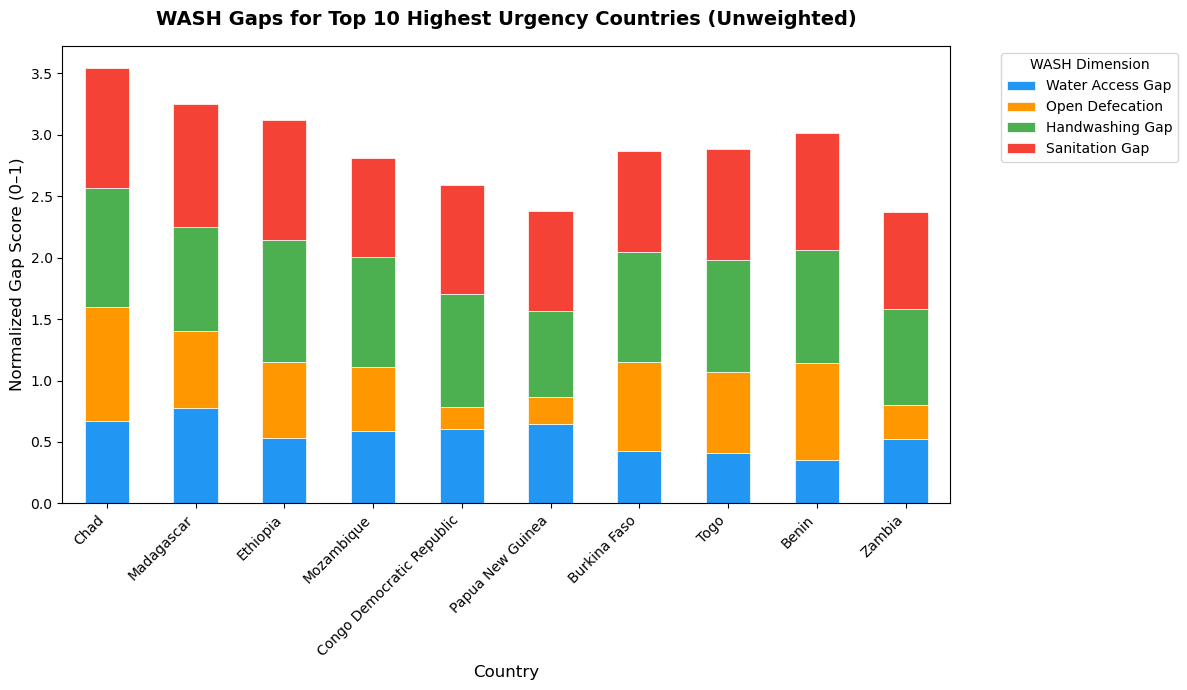

In [106]:
# Chart 3: Top 10 — Unweighted Gap
# This chart shows the raw normalized gap for each WASH dimension across the 10 most urgent countries. It tells us which dimensions are most deficient in each country, without factoring in impact weights.

plot_gap = top10.set_index('country')[[
    'improved_water_gap', 'open_defecation_gap',
    'handwashing_gap', 'sanitation_gap'
]]
plot_gap.columns = ['Water Access Gap', 'Open Defecation',
                    'Handwashing Gap', 'Sanitation Gap']
 
fig, ax = plt.subplots(figsize=(12, 7))
plot_gap.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2196F3', '#FF9800', '#4CAF50', '#F44336'],
    edgecolor='white', linewidth=0.5
)
ax.set_title('WASH Gaps for Top 10 Highest Urgency Countries (Unweighted)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Normalized Gap Score (0–1)', fontsize=12)
ax.set_xticklabels(plot_gap.index, rotation=45, ha='right')
ax.legend(title='WASH Dimension', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("chart3_top10_gap.png", dpi=150, bbox_inches='tight')
plt.show()

The figure decomposes the WASH Investment Urgency Index for the 10 highest-priority countries. Water access gaps are the largest contributor in most countries, followed by handwashing, sanitation, and open defecation. The results suggest that improving access to safe water should be the primary investment priority, with complementary interventions tailored to country-specific needs.

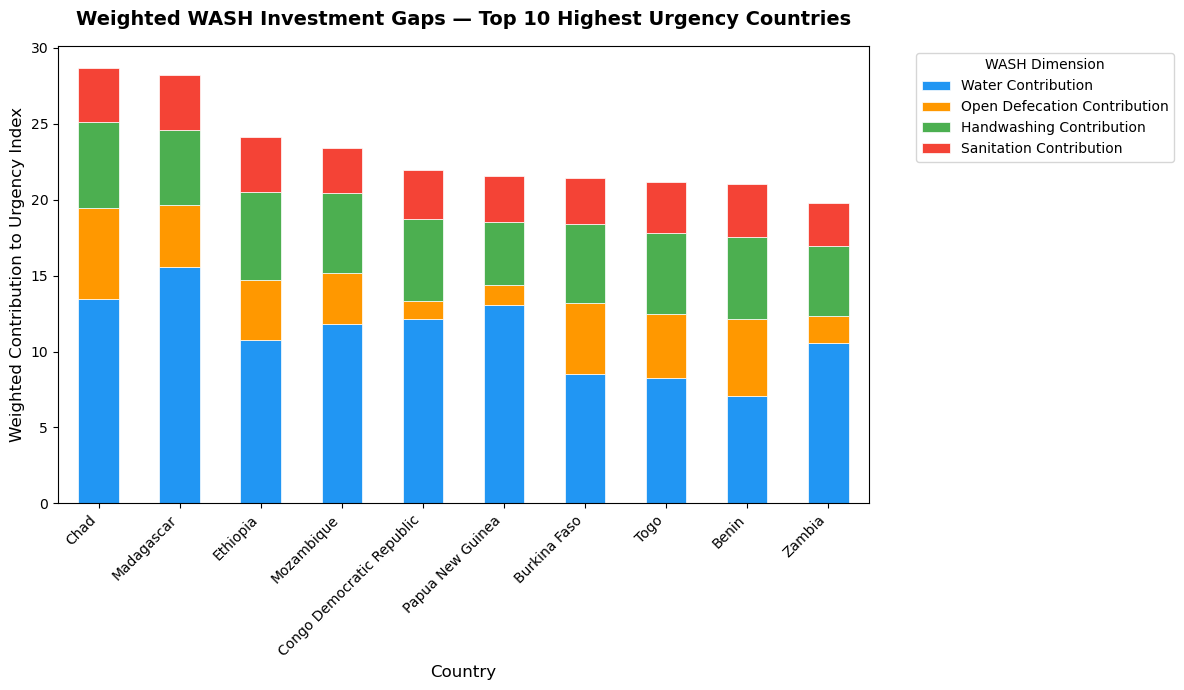

In [108]:
# Chart 4: Top 10 — Weighted Gap (gap × regression coefficient)
# This chart shows the weighted contribution of each WASH dimension to the Urgency Index. Each bar segment reflects both how large the gap is and how much that dimension matters for child health outcomes.
# This is the most actionable chart for NGOs deciding where to invest.

top10['Water Contribution']           = top10['improved_water_gap']  * 20.108465
top10['Open Defecation Contribution'] = top10['open_defecation_gap'] *  6.426036
top10['Handwashing Contribution']     = top10['handwashing_gap']     *  5.868629
top10['Sanitation Contribution']      = top10['sanitation_gap']      *  3.660238
 
plot_weighted = top10.set_index('country')[[
    'Water Contribution', 'Open Defecation Contribution',
    'Handwashing Contribution', 'Sanitation Contribution'
]]
 
fig, ax = plt.subplots(figsize=(12, 7))
plot_weighted.plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2196F3', '#FF9800', '#4CAF50', '#F44336'],
    edgecolor='white', linewidth=0.5
)
ax.set_title('Weighted WASH Investment Gaps — Top 10 Highest Urgency Countries',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Weighted Contribution to Urgency Index', fontsize=12)
ax.set_xticklabels(plot_weighted.index, rotation=45, ha='right')
ax.legend(title='WASH Dimension', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("chart4_top10_weighted.png", dpi=150, bbox_inches='tight')
plt.show()

When we weight the investment gaps by the corresponding coefficient, water access is the dominant driver of WASH investment urgency in most high-priority countries, while handwashing, sanitation, and open defecation contribute to varying degrees. The results suggest that expanding access to safe water should be the primary focus of investment.

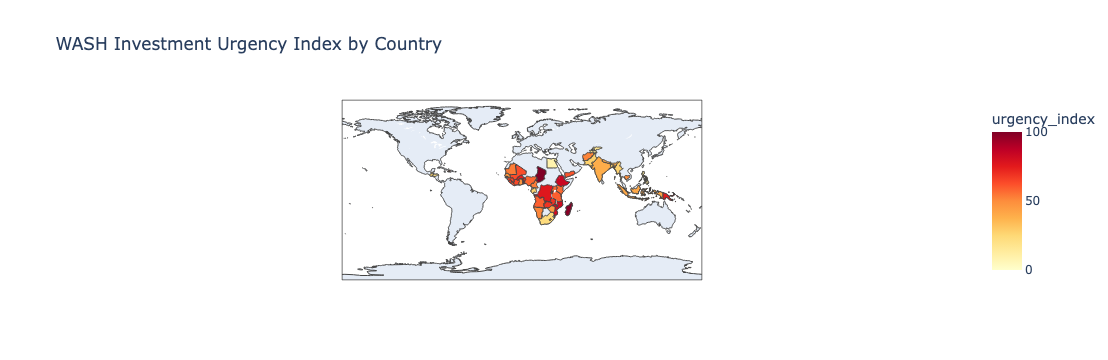

In [110]:
# WORLD MAP

fig = px.choropleth(
    country_df,
    locations='iso3',
    color='urgency_index',
    hover_name='country',
    hover_data=['urgency_level'],
    color_continuous_scale='YlOrRd',
    title='WASH Investment Urgency Index by Country'
)

fig.show()

Note: The map only includes countries covered by the DHS Program survey data. 
High-income countries are not included as they are outside the scope of DHS data collection.
Grey areas indicate no data available.

The map highlights substantial geographic variation in WASH investment needs. The highest urgency scores are concentrated in Sub-Saharan Africa, indicating that these countries face the largest urgency needs. A smaller number of high-priority countries also appear in South Asia and Southeast Asia. 

# Conclusion

The analysis finds that WASH variables, such as open defecation, handwashing, sanitation, and improved water, are strongly correlated with poorer health outcomes, especially under-5 mortality.

The WASH Investment Urgency Index identifies a group of high-priority countries, many of which are located in Sub-Saharan Africa. Decomposition of the index further shows that water access gaps contribute the largest share of urgency in most countries, suggesting that expanding access to safe water should be a central focus of future WASH investments. Within those countries, Chad and Madagascar are the two countries that need investments. 

While the findings provide useful guidance for prioritizing resources, several limitations remain. 
1. The analysis is based on country-level averages and cannot fully capture within-country inequalities. Future work could also use subnational data to identify high-need regions within countries and develop more targeted policy recommendations.
2. Additionally, further work could also use data to quantify the costs and benefits of investment to make more informed decisions. 